In [ ]:
#Regression Analysis used for Classification

# Import Libraries and Mount the file in google

In [43]:
#Data management
import pandas as pd
import numpy as np
#Visual Exploration
import matplotlib.pyplot as plt
import seaborn as sns

#Scikit learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix
#Statsmodels

import statsmodels.api as sm

In [1]:
#mount to google
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Creating a data frame from the file Universal Bank
path="/content/drive/My Drive/Skillup/UniversalBankV1.csv"

df=pd.read_csv(path)

#Exploratory Data Analysis and Feature Engineering

In [14]:
df.head(10)
#print("the shape of the dataset is",df.shape)

,ID,Age,Work Experience,Income,Family Size,Credit Card Avg,Education,Mortgage,Securities Account,CD Account,Online Banking,Credit Card,Personal Loan
0,1,25,1,49,4,1.6,1,0,1,0,0,0,0
1,2,45,19,34,3,1.5,1,0,1,0,0,0,0
2,3,39,15,11,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,4,1.0,2,0,0,0,0,1,0
5,6,37,13,29,4,0.4,2,155,0,0,1,0,0
6,7,53,27,72,2,1.5,2,0,0,0,1,0,0
7,8,50,24,22,1,0.3,3,0,0,0,0,1,0
8,9,35,10,81,3,0.6,2,104,0,0,1,0,0
9,10,34,9,180,1,8.9,3,0,0,0,0,0,1


In [12]:
#df.info()
#check the distribution of the target variable
target_distribution=df['Personal Loan'].value_counts(normalize=True)
target_distribution


,proportion
Personal Loan,
0,0.8976
1,0.1024


In [20]:
df.describe()

,ID,Age,Work Experience,Income,Family Size,Credit Card Avg,Education,Mortgage,Securities Account,CD Account,Online Banking,Credit Card,Personal Loan
count,2500.00000,2500.000000,2500.000000,2500.0000,2500.00000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000
mean,1250.50000,45.346000,20.132400,74.4472,2.40800,1.951284,1.86560,57.388400,0.109600,0.062400,0.59760,0.290400,0.102400
std,721.83216,11.519521,11.502826,46.6724,1.15986,1.795449,0.83655,100.816403,0.312453,0.241929,0.49048,0.454038,0.303234
min,1.00000,23.000000,0.000000,8.0000,1.00000,0.000000,1.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,625.75000,35.000000,10.000000,39.0000,1.00000,0.700000,1.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,1250.50000,45.000000,20.000000,64.0000,2.00000,1.500000,2.00000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000
75%,1875.25000,55.000000,30.000000,99.2500,4.00000,2.500000,3.00000,104.000000,0.000000,0.000000,1.00000,1.000000,0.000000
max,2500.00000,67.000000,42.000000,205.0000,4.00000,10.000000,3.00000,617.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [21]:
#Drop the variable ID
df1=df.drop(['ID'],axis=1)
df1.head()

,Age,Work Experience,Income,Family Size,Credit Card Avg,Education,Mortgage,Securities Account,CD Account,Online Banking,Credit Card,Personal Loan
0,25,1,49,4,1.6,1,0,1,0,0,0,0
1,45,19,34,3,1.5,1,0,1,0,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,1,0


In [23]:
#Convert Education into Dummy variables
#df1=pd.get_dummies(df1,columns=['Education'],drop_first=True)
#Convert Education_2 and Education_3 from boolean to 0 ,1
df1['Education_2']=df1['Education_2'].astype(int)
df1['Education_3']=df1['Education_3'].astype(int)
df1.head()

,Age,Work Experience,Income,Family Size,Credit Card Avg,Mortgage,Securities Account,CD Account,Online Banking,Credit Card,Personal Loan,Education_2,Education_3
0,25,1,49,4,1.6,0,1,0,0,0,0,0,0
1,45,19,34,3,1.5,0,1,0,0,0,0,0,0
2,39,15,11,1,1.0,0,0,0,0,0,0,0,0
3,35,9,100,1,2.7,0,0,0,0,0,0,1,0
4,35,8,45,4,1.0,0,0,0,0,1,0,1,0


In [ ]:
sns.pairplot(df1)

In [ ]:
correlation_matrix=df1.corr()
correlation_matrix

#Display a heat map
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.show()

# Prepare the Data for Modelling

In [ ]:
X=df1.drop(['Personal Loan'],axis=1)
y=df1['Personal Loan']



In [ ]:
#apply a MinMax Scaler
scaler = MinMaxScaler()
X_scaled=scaler.fit_transform(X)
X_scaled

In [32]:
#Split the dataset into a training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=50)

In [33]:
#train the linear model by using Scikitlearn
model=LinearRegression()
model.fit(X_train,y_train)
#Bring summary table


LinearRegression()

In [39]:
y_pred_linear=model.predict(X_test)
Xtdf=pd.DataFrame(X_test)
Xtdf['y_pred_linear']=y_pred_linear
#incorporate original headings
Xtdf


,0,1,2,3,4,5,6,7,8,9,10,11,y_pred_linear
0,0.159091,0.119048,0.675127,0.000000,0.08,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.157445
1,0.750000,0.738095,0.223350,0.666667,0.20,0.000000,1.0,1.0,1.0,1.0,1.0,0.0,0.369281
2,0.704545,0.666667,0.126904,0.333333,0.07,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,-0.023767
3,0.045455,0.023810,0.101523,0.000000,0.10,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,-0.049842
4,0.068182,0.047619,0.487310,0.666667,0.25,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.131829
...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,0.659091,0.595238,0.873096,0.333333,0.90,0.481361,0.0,0.0,1.0,0.0,1.0,0.0,0.569496
746,0.772727,0.761905,0.588832,0.000000,0.02,0.000000,0.0,0.0,1.0,0.0,1.0,0.0,0.265200
747,0.272727,0.214286,0.868020,0.333333,0.00,0.123177,1.0,0.0,1.0,0.0,0.0,0.0,0.230341
748,0.272727,0.238095,0.791878,0.333333,0.78,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.351188


In [58]:
Threshold=0.4
y_class_pred=(y_pred_linear >=Threshold ).astype(int)
Xtdf['PredBinary']=y_class_pred
Xtdf

,0,1,2,3,4,5,6,7,8,9,10,11,y_pred_linear,PredBinary
0,0.159091,0.119048,0.675127,0.000000,0.08,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.157445,0
1,0.750000,0.738095,0.223350,0.666667,0.20,0.000000,1.0,1.0,1.0,1.0,1.0,0.0,0.369281,0
2,0.704545,0.666667,0.126904,0.333333,0.07,0.000000,0.0,0.0,0.0,1.0,1.0,0.0,-0.023767,0
3,0.045455,0.023810,0.101523,0.000000,0.10,0.000000,0.0,0.0,1.0,0.0,0.0,1.0,-0.049842,0
4,0.068182,0.047619,0.487310,0.666667,0.25,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.131829,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,0.659091,0.595238,0.873096,0.333333,0.90,0.481361,0.0,0.0,1.0,0.0,1.0,0.0,0.569496,1
746,0.772727,0.761905,0.588832,0.000000,0.02,0.000000,0.0,0.0,1.0,0.0,1.0,0.0,0.265200,0
747,0.272727,0.214286,0.868020,0.333333,0.00,0.123177,1.0,0.0,1.0,0.0,0.0,0.0,0.230341,0
748,0.272727,0.238095,0.791878,0.333333,0.78,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.351188,0


In [59]:
#Confusion matrix
conf_matrix=confusion_matrix(y_test,y_class_pred)
conf_matrix


array([[664,  13],
       [ 26,  47]])

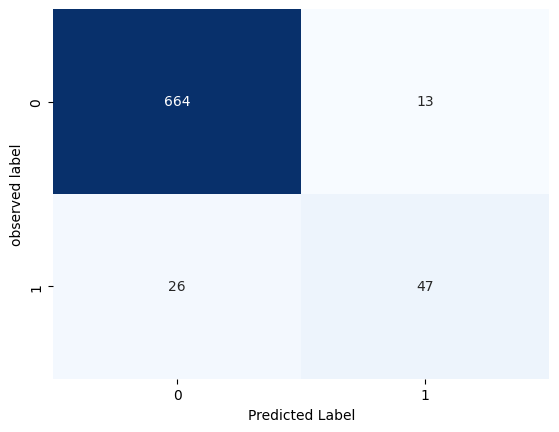

In [60]:
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap='Blues', cbar=False)

plt.xlabel('Predicted Label')
plt.ylabel('observed label')
plt.show()


In [61]:
#Accuracy
accuracy_score(y_test, y_class_pred)

#Classification Report


0.948